# 03 — ELO Ratings, Feature Engineering & XGBoost
**FIFA 2026 World Cup Predictor**

This notebook builds the full ML pipeline:
1. **ELO ratings** — dynamic team strength computed over 928 historical matches
2. **Feature engineering** — rolling form, head-to-head stats, ELO diff
3. **XGBoost classifier** — predicts Home Win / Draw / Away Win probabilities
4. **Hybrid prediction** — blends XGBoost (70%) + Poisson model (30%)
5. **Visualisations** — ELO rankings, feature importances, calibration


## Install & imports

In [1]:
!pip install xgboost scikit-learn pandas numpy scipy matplotlib -q

In [1]:
import pandas as pd
import numpy as np
import pickle
import warnings
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.stats import poisson
from sklearn.model_selection import cross_val_score, StratifiedKFold, learning_curve
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.calibration import CalibrationDisplay
import xgboost as xgb

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
np.random.seed(42)
print("All imports OK")

All imports OK


## 1. Load clean data

In [2]:
df_hist = pd.read_csv("data/historical_data.csv")
df_fixture = pd.read_csv("data/fixture_2026.csv")
dict_table = pickle.load(open("data/dict_table_2026", "rb"))

print(f"Historical matches: {len(df_hist)}")
print(f"Years: {df_hist['Year'].min()} – {df_hist['Year'].max()}")
print(f"Fixture rows: {len(df_fixture)}")
print(f"Groups: {list(dict_table.keys())}")
df_hist.head()

Historical matches: 928
Years: 1930 – 2022
Fixture rows: 104
Groups: ['Group A', 'Group B', 'Group C', 'Group D', 'Group E', 'Group F', 'Group G', 'Group H', 'Group I', 'Group J', 'Group K', 'Group L']


,HomeTeam,AwayTeam,Year,HomeGoals,AwayGoals,TotalGoals,Outcome
0,France,Mexico,1930,4,1,5,HomeTeam Win
1,Argentina,France,1930,1,0,1,HomeTeam Win
2,Chile,Mexico,1930,3,0,3,HomeTeam Win
3,Chile,France,1930,1,0,1,HomeTeam Win
4,Argentina,Mexico,1930,6,3,9,HomeTeam Win


## 2. ELO Rating System

ELO is a dynamic strength rating. Key properties:
- Every team starts at **1500**
- Winning earns points, losing loses them
- **Bigger wins** (goal difference) → larger update via a multiplier
- Home advantage = **+50 ELO** added to the home team's rating before computing expected scores
- After every match: `new_ELO = old_ELO + K × GD_mult × (actual − expected)`
- **`DECAY_RATE = 0.60`** — shrinks each team's ELO gap from 1500 by 40% every year, ensuring recent form matters more than historical dominance

In [8]:
K_FACTOR    = 32
HOME_ADV    = 50
INITIAL_ELO = 1500
DECAY_RATE  = 0.85    # ← ADD THIS

def expected_score(ra, rb):
    return 1 / (1 + 10 ** ((rb - ra) / 400))

def gd_multiplier(gd: int) -> float:
    if gd <= 1:   return 1.00
    elif gd == 2: return 1.50
    elif gd == 3: return 1.75
    else:         return 2.00

def compute_elo(df: pd.DataFrame):
    elo = {}
    records = []
    current_year = None          # ← ADD THIS

    for _, row in df.sort_values("Year").iterrows():
        home, away = row["HomeTeam"], row["AwayTeam"]
        hg,   ag   = row["HomeGoals"], row["AwayGoals"]

        # ── ADD THIS BLOCK ──────────────────────────────────────
        if current_year is not None and row["Year"] != current_year:
            for team in elo:
                elo[team] = INITIAL_ELO + (elo[team] - INITIAL_ELO) * DECAY_RATE
        current_year = row["Year"]
        # ────────────────────────────────────────────────────────

        elo.setdefault(home, INITIAL_ELO)
        elo.setdefault(away, INITIAL_ELO)

        exp_h = expected_score(elo[home] + HOME_ADV, elo[away])
        s_h   = 1.0 if hg > ag else (0.5 if hg == ag else 0.0)
        mult  = gd_multiplier(abs(hg - ag))

        records.append({
            "HomeTeam": home, "AwayTeam": away, "Year": row["Year"],
            "HomeGoals": hg,  "AwayGoals": ag,
            "HomeELO":   elo[home], "AwayELO": elo[away],
            "ELO_diff":  elo[home] - elo[away],
        })

        elo[home] += K_FACTOR * mult * (s_h       - exp_h)
        elo[away] += K_FACTOR * mult * ((1 - s_h) - (1 - exp_h))

    return elo, pd.DataFrame(records)

elo_dict, df_elo = compute_elo(df_hist)
print(f"ELO computed for {len(elo_dict)} teams")
pd.DataFrame(sorted(elo_dict.items(), key=lambda x: -x[1]),
             columns=["Team", "ELO"]).head(10)

ELO computed for 85 teams


,Team,ELO
0,Netherlands,1660.801375
1,France,1658.871775
2,Brazil,1615.940891
3,Germany,1609.163466
4,Argentina,1606.854468
5,England,1580.260720
6,Belgium,1575.486170
7,Croatia,1568.262376
8,Spain,1556.465946
9,Colombia,1556.252519


### ELO Rankings — visualised

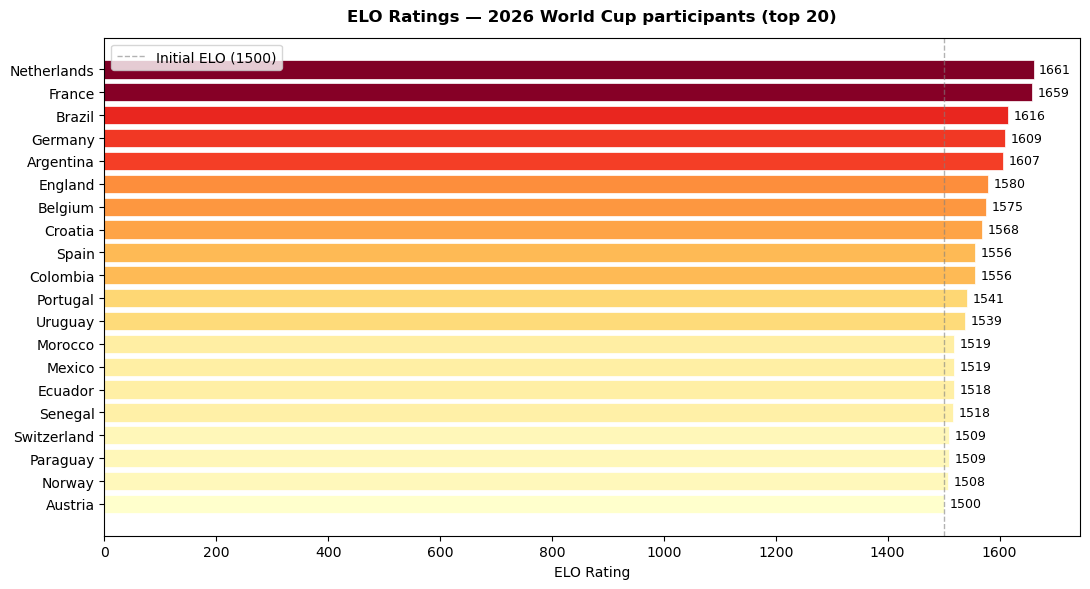

In [9]:
elo_df = pd.DataFrame(sorted(elo_dict.items(), key=lambda x: -x[1]), columns=["Team", "ELO"])
elo_df.to_csv("outputs/elo_ratings.csv", index=False)

# Keep only 2026 participants for the chart
participants_2026 = set()
for g, tbl in dict_table.items():
    for t in tbl["Team"]:
        participants_2026.add(str(t).replace("(H)","").replace("[a]","").strip())

elo_2026 = elo_df[elo_df["Team"].isin(participants_2026)].head(20).copy()
colors_elo = cm.YlOrRd(
    (elo_2026["ELO"] - elo_2026["ELO"].min()) /
    (elo_2026["ELO"].max() - elo_2026["ELO"].min())
).tolist()

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(elo_2026["Team"][::-1], elo_2026["ELO"][::-1],
               color=colors_elo[::-1], edgecolor="white", linewidth=0.5)
ax.bar_label(bars, labels=[f"{v:.0f}" for v in elo_2026["ELO"][::-1]], padding=4, fontsize=9)
ax.axvline(1500, color="gray", linestyle="--", linewidth=1, alpha=0.6, label="Initial ELO (1500)")
ax.set_title("ELO Ratings — 2026 World Cup participants (top 20)", fontweight="bold", pad=12)
ax.set_xlabel("ELO Rating")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/elo_rankings.png", dpi=140, bbox_inches="tight")
plt.show()

### ELO evolution over time — top 6 teams

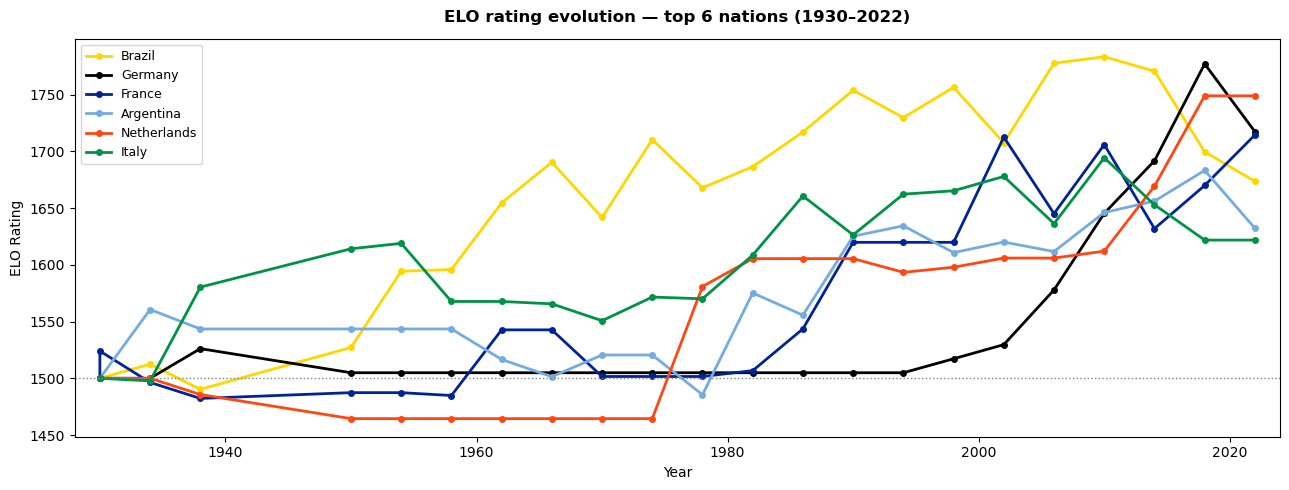

In [10]:
top6 = ["Brazil", "Germany", "France", "Argentina", "Netherlands", "Italy"]
colors6 = ["#FFD700", "#000000", "#002395", "#74ACDF", "#FF4713", "#009246"]

# recompute tracking elo over time
elo_track = {t: [INITIAL_ELO] for t in top6}
years_track = []

elo_tmp = {}
for _, row in df_hist.sort_values("Year").iterrows():
    home, away = row["HomeTeam"], row["AwayTeam"]
    hg, ag = row["HomeGoals"], row["AwayGoals"]
    elo_tmp.setdefault(home, INITIAL_ELO)
    elo_tmp.setdefault(away, INITIAL_ELO)

    exp_h = expected_score(elo_tmp[home] + HOME_ADV, elo_tmp[away])
    s_h   = 1.0 if hg > ag else (0.5 if hg == ag else 0.0)
    mult  = gd_multiplier(abs(hg - ag))
    elo_tmp[home] += K_FACTOR * mult * (s_h - exp_h)
    elo_tmp[away] += K_FACTOR * mult * ((1-s_h) - (1-exp_h))

    if row["Year"] not in years_track:
        years_track.append(row["Year"])
        for t in top6:
            elo_track[t].append(elo_tmp.get(t, INITIAL_ELO))

fig, ax = plt.subplots(figsize=(13, 5))
x_vals = [1930] + years_track
for team, color in zip(top6, colors6):
    vals = elo_track[team][:len(x_vals)]
    ax.plot(x_vals[:len(vals)], vals, "o-", color=color, label=team,
            linewidth=2, markersize=4)

ax.axhline(1500, color="gray", linestyle=":", linewidth=1)
ax.set_title("ELO rating evolution — top 6 nations (1930–2022)", fontweight="bold", pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("ELO Rating")
ax.legend(loc="upper left", fontsize=9)
ax.set_xlim(1928, 2024)
plt.tight_layout()
plt.savefig("outputs/elo_evolution.png", dpi=140, bbox_inches="tight")
plt.show()

## 3. Feature Engineering

For each match we compute **9 features**, all calculated from data available *before* that match (no data leakage):

| Feature | Description |
|---|---|
| `HomeELO` | Home team ELO before the match |
| `AwayELO` | Away team ELO before the match |
| `ELO_diff` | HomeELO − AwayELO |
| `HomeFormScored` | Home team avg goals scored (last 10 matches) |
| `HomeFormConceded` | Home team avg goals conceded (last 10 matches) |
| `AwayFormScored` | Away team avg goals scored (last 10 matches) |
| `AwayFormConceded` | Away team avg goals conceded (last 10 matches) |
| `H2H_HomeWinRate` | Historical home win rate in this specific matchup |
| `H2H_DrawRate` | Historical draw rate in this specific matchup |

In [11]:
LOOKBACK = 15   # rolling form window

def build_features(df_elo: pd.DataFrame):
    df = df_elo.copy().reset_index(drop=True)
    team_stats = {}   # team → [(scored, conceded), ...]

    rows_hfs, rows_hfc, rows_afs, rows_afc = [], [], [], []
    rows_h2h_hw, rows_h2h_dr = [], []

    for i, row in df.iterrows():
        h, a = row["HomeTeam"], row["AwayTeam"]
        for t in [h, a]: team_stats.setdefault(t, [])

        h_hist = team_stats[h][-LOOKBACK:]
        a_hist = team_stats[a][-LOOKBACK:]

        rows_hfs.append(np.mean([x[0] for x in h_hist]) if h_hist else 1.5)
        rows_hfc.append(np.mean([x[1] for x in h_hist]) if h_hist else 1.2)
        rows_afs.append(np.mean([x[0] for x in a_hist]) if a_hist else 1.5)
        rows_afc.append(np.mean([x[1] for x in a_hist]) if a_hist else 1.2)

        # H2H from all PRIOR rows only
        prior = df.iloc[:i]
        mask  = (
            ((prior["HomeTeam"] == h) & (prior["AwayTeam"] == a)) |
            ((prior["HomeTeam"] == a) & (prior["AwayTeam"] == h))
        )
        h2h = prior[mask]
        if len(h2h) == 0:
            rows_h2h_hw.append(0.33); rows_h2h_dr.append(0.33)
        else:
            hw = len(h2h[(h2h["HomeTeam"]==h) & (h2h["HomeGoals"] > h2h["AwayGoals"])])
            dr = len(h2h[h2h["HomeGoals"] == h2h["AwayGoals"]])
            rows_h2h_hw.append(hw / len(h2h))
            rows_h2h_dr.append(dr / len(h2h))

        team_stats[h].append((row["HomeGoals"], row["AwayGoals"]))
        team_stats[a].append((row["AwayGoals"], row["HomeGoals"]))

    df["HomeFormScored"]   = rows_hfs
    df["HomeFormConceded"] = rows_hfc
    df["AwayFormScored"]   = rows_afs
    df["AwayFormConceded"] = rows_afc
    df["H2H_HomeWinRate"]  = rows_h2h_hw
    df["H2H_DrawRate"]     = rows_h2h_dr

    df["Outcome"] = df.apply(
        lambda r: 2 if r["HomeGoals"] > r["AwayGoals"]
                  else (1 if r["HomeGoals"] == r["AwayGoals"] else 0),
        axis=1
    )
    return df, team_stats

df_feat, team_stats = build_features(df_elo)
print(f"Feature matrix: {df_feat.shape}")
print(f"Outcome distribution: {df_feat['Outcome'].value_counts().to_dict()} (0=away, 1=draw, 2=home)")
df_feat[["HomeTeam","AwayTeam","Year","HomeELO","AwayELO","ELO_diff",
         "HomeFormScored","AwayFormScored","H2H_HomeWinRate","Outcome"]].sample(8)

Feature matrix: (928, 15)
Outcome distribution: {2: 507, 0: 215, 1: 206} (0=away, 1=draw, 2=home)


,HomeTeam,AwayTeam,Year,HomeELO,AwayELO,ELO_diff,HomeFormScored,AwayFormScored,H2H_HomeWinRate,Outcome
755,Argentina,Switzerland,2014,1593.918074,1520.697819,73.220254,1.733333,0.733333,1.00,2
668,Mexico,Iran,2006,1486.875325,1475.605805,11.269520,1.200000,0.714286,0.33,2
30,Italy,United States,1934,1537.461254,1518.026792,19.434462,1.250000,2.333333,0.33,2
388,Argentina,South Korea,1986,1585.788762,1487.455174,98.333588,1.933333,0.000000,0.33,2
192,England,Mexico,1966,1556.046266,1436.646998,119.399268,1.600000,0.800000,0.33,2
355,England,Czechoslovakia,1982,1560.567952,1481.626115,78.941837,1.266667,1.266667,1.00,2
107,Soviet Union,England,1958,1505.173354,1504.237308,0.936046,1.333333,1.555556,0.00,2
487,Romania,England,1998,1511.780090,1558.420598,-46.640508,1.533333,1.333333,0.00,2


## 4. Train XGBoost Classifier

In [12]:
FEATURE_COLS = [
    "HomeELO", "AwayELO", "ELO_diff",
    "HomeFormScored", "HomeFormConceded",
    "AwayFormScored", "AwayFormConceded",
    "H2H_HomeWinRate", "H2H_DrawRate",
]

X = df_feat[FEATURE_COLS].values
y = df_feat["Outcome"].values


# Compute weights so all 3 classes are treated equally
sample_weights = compute_sample_weight(class_weight='balanced', y=y)

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.04,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    eval_metric="mlogloss",
    random_state=42,
    verbosity=0,
)

# Pass weights during fit
model.fit(X, y, sample_weight=sample_weights)
0
# 5-fold cross-validation
cv = cross_val_score(model, X, y,
                     cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                     scoring="accuracy")
print(f"5-fold CV accuracy: {cv.mean():.3f} ± {cv.std():.3f}")
print(f"Random baseline:    {1/3:.3f}")
print(f"Lift over random:   {cv.mean() - 1/3:.3f}")

5-fold CV accuracy: 0.552 ± 0.017
Random baseline:    0.333
Lift over random:   0.218


### Feature importances

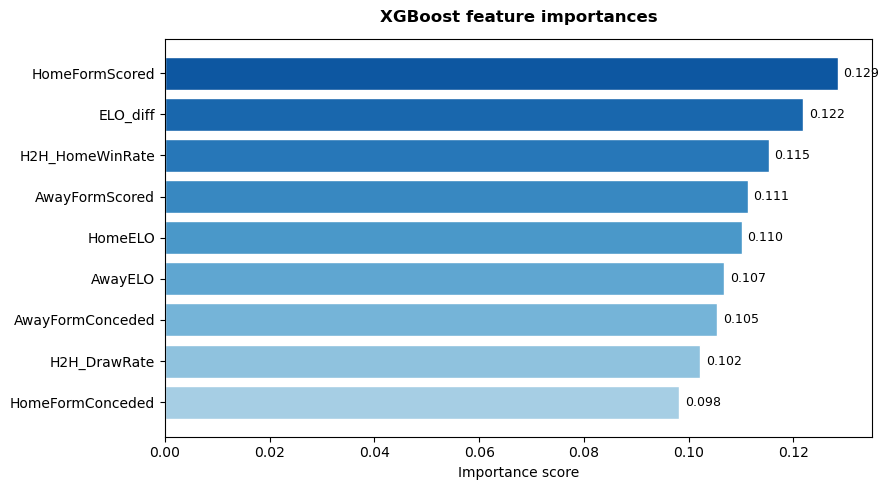

In [13]:
fi_df = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors_fi = cm.Blues(np.linspace(0.35, 0.85, len(fi_df)))
bars = ax.barh(fi_df["Feature"], fi_df["Importance"], color=colors_fi, edgecolor="white")
ax.bar_label(bars, labels=[f"{v:.3f}" for v in fi_df["Importance"]], padding=4, fontsize=9)
ax.set_title("XGBoost feature importances", fontweight="bold", pad=12)
ax.set_xlabel("Importance score")
plt.tight_layout()
plt.savefig("outputs/feature_importances.png", dpi=140, bbox_inches="tight")
plt.show()

fi_df.sort_values("Importance", ascending=False).to_csv("outputs/feature_importances.csv", index=False)

### Confusion matrix

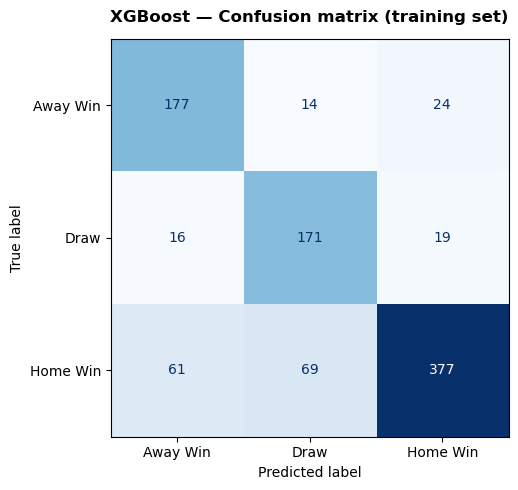

              precision    recall  f1-score   support

    Away Win       0.70      0.82      0.75       215
        Draw       0.67      0.83      0.74       206
    Home Win       0.90      0.74      0.81       507

    accuracy                           0.78       928
   macro avg       0.76      0.80      0.77       928
weighted avg       0.80      0.78      0.78       928



In [14]:
y_pred = model.predict(X)
cm_arr = confusion_matrix(y, y_pred)
labels = ["Away Win", "Draw", "Home Win"]

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_arr, display_labels=labels)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("XGBoost — Confusion matrix (training set)", fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png", dpi=140, bbox_inches="tight")
plt.show()
print(classification_report(y, y_pred, target_names=labels))

## 5. Hybrid Prediction Function

Final probability = **70% XGBoost + 30% Poisson** for stability.

In [15]:
def predict_match(home, away, elo_dict, team_stats, model,
                  weight_ml=0.7, lookback=10):
    """
    Predict match outcome probabilities using hybrid XGBoost + Poisson model.
    Returns (p_home_win, p_draw, p_away_win).
    """
    h_elo = elo_dict.get(home, INITIAL_ELO)
    a_elo = elo_dict.get(away, INITIAL_ELO)

    h_hist = team_stats.get(home, [])[-lookback:]
    a_hist = team_stats.get(away, [])[-lookback:]
    hfs = np.mean([x[0] for x in h_hist]) if h_hist else 1.5
    hfc = np.mean([x[1] for x in h_hist]) if h_hist else 1.2
    afs = np.mean([x[0] for x in a_hist]) if a_hist else 1.5
    afc = np.mean([x[1] for x in a_hist]) if a_hist else 1.2

    # Poisson model
    lh, la = max(hfs * afc, 0.3), max(afs * hfc, 0.3)
    ph = pd_ = pa = 0.0
    for x in range(9):
        for y_s in range(9):
            p = poisson.pmf(x, lh) * poisson.pmf(y_s, la)
            if x > y_s:   ph  += p
            elif x == y_s: pd_ += p
            else:          pa  += p

    # XGBoost model
    # xcap ELO diff to prevent extreme probabilities
    elo_diff_capped = max(min(h_elo - a_elo, 200), -200)

    x_feat = np.array([[
    h_elo, a_elo, elo_diff_capped,   # ← use capped diff
    hfs, hfc, afs, afc, 0.33, 0.33
    ]])
    ml     = model.predict_proba(x_feat)[0]   # [away, draw, home]

    p_h = weight_ml*ml[2] + (1-weight_ml)*ph
    p_d = weight_ml*ml[1] + (1-weight_ml)*pd_
    p_a = weight_ml*ml[0] + (1-weight_ml)*pa
    t   = p_h + p_d + p_a
    return p_h/t, p_d/t, p_a/t

# Sanity-check predictions
print(f"{'Match':<35}  {'Home':>6}  {'Draw':>6}  {'Away':>6}")
print("-" * 58)
test_matches = [
    ("France",      "Brazil"),
    ("Argentina",   "Germany"),
    ("Spain",       "England"),
    ("Netherlands", "Portugal"),
    ("Belgium",     "Colombia"),
    ("Brazil",      "Netherlands"),
    ("Netherlands", "France")
]
for h, a in test_matches:
    ph, pd_, pa = predict_match(h, a, elo_dict, team_stats, model)
    print(f"  {h:<15} vs {a:<15}  {ph:>5.1%}  {pd_:>5.1%}  {pa:>5.1%}")

Match                                  Home    Draw    Away
----------------------------------------------------------
  France          vs Brazil           15.7%  27.8%  56.5%
  Argentina       vs Germany          24.0%  27.9%  48.1%
  Spain           vs England          27.5%  32.5%  40.0%
  Netherlands     vs Portugal         67.3%  22.9%   9.8%
  Belgium         vs Colombia         29.6%  35.8%  34.6%
  Brazil          vs Netherlands      15.3%  27.8%  57.0%
  Netherlands     vs France           26.2%  18.7%  55.0%


## 6. Save model artefacts

In [16]:
with open("outputs/model.pkl",      "wb") as f: pickle.dump(model,      f)
with open("outputs/elo_dict.pkl",   "wb") as f: pickle.dump(elo_dict,   f)
with open("outputs/team_stats.pkl", "wb") as f: pickle.dump(team_stats, f)
print("Saved: model.pkl, elo_dict.pkl, team_stats.pkl")

Saved: model.pkl, elo_dict.pkl, team_stats.pkl
